# Credit Card Fraud Detection

In [17]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt


In [18]:
#Loading data 
data= pd.read_csv("C:\\Users\\ALLAIE HAZU\\OneDrive\\Documents\\Desktop\\JOURNEY\\PROJECT\\Credit-Card-Fraud-Detection\\creditcard.csv")
df = pd.DataFrame(data)

#   EDA


In [4]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [8]:
print(df.shape)
print(df.columns.tolist())

(284807, 31)
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [9]:
print(df.dtypes)

Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object


In [ ]:
#Mising Values
print(df.isnull().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [ ]:
# Class imbalance 
print(df['Class'].value_counts())
print(df['Class'].value_counts(normalize=True) * 100)

#1 MEANS FRAUD AND 0 MEANS not fraud 


Class
0    284315
1       492
Name: count, dtype: int64
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


highly imbalanced data set .Need to balance the data set 

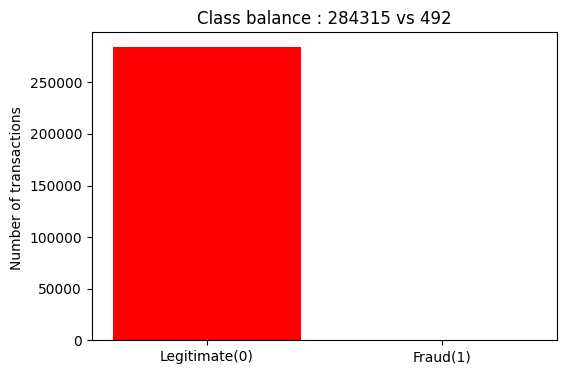

Legitimate :99.83% | Fraud : 0.17%


In [16]:
counts = df["Class"].value_counts()
plt.figure(figsize=(6,4))
plt.bar(["Legitimate(0)",'Fraud(1)'],counts.values,color=['red',"blue"])
plt.ylabel( "Number of transactions ")
plt.title("Class balance : 284315 vs 492")
plt.show ()

#percentage Labels
print(f"Legitimate :{counts[0]/len(df) *100 :.2f}% | Fraud :{counts[1]/len(df)*100: .2f}%")

======Amount stats - Legitimate Transactions(0) ======
count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

======Amount stats - Fraud Transactions(1) ======
count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64


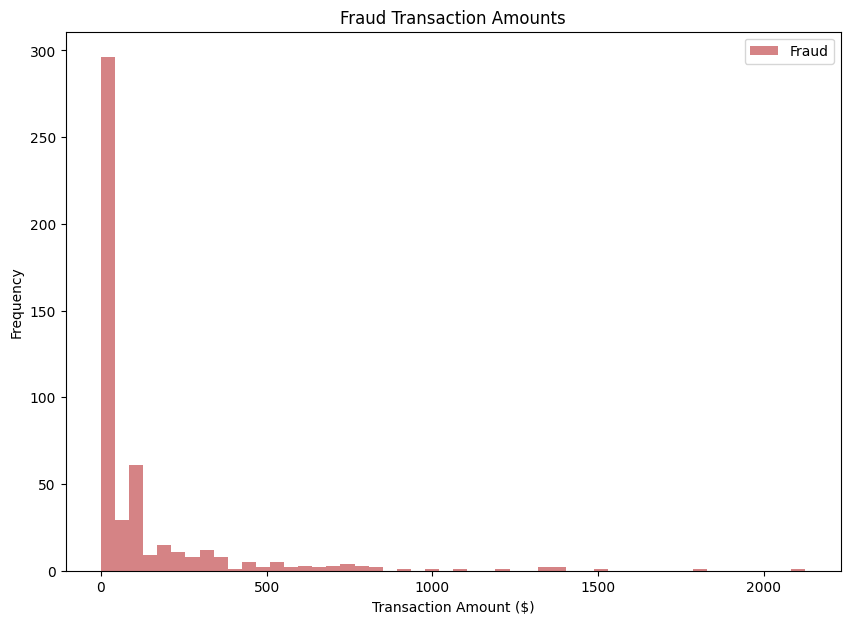

In [26]:
#Amount distribution by class 
print ( "======Amount stats - Legitimate Transactions(0) ======")
print (df[df["Class"]== 0]['Amount'].describe()) # Gives stats of non fraud transaction amount 


print ( "\n======Amount stats - Fraud Transactions(1) ======")
print (df[df["Class"]==1]['Amount'].describe())

#Visuals 
plt.figure(figsize=(10,7))
plt.hist(df[df["Class"]==1]["Amount"],bins=50, color = "#C44E52",alpha=0.7,label='Fraud')
plt.xlabel("Transaction Amount ($)")
plt.ylabel("Frequency")

plt.title("Fraud Transaction Amounts")
plt.legend()
plt.show()


The histogram and stats show that fraud transaction happen with small in amount in large amount with large amount in small range 